In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM



In [ ]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "Askap_flyeye"
# ============================================================================

# Telescope parameters dictionary
TELESCOPE_PARAMS = {

        "askap_flyeye": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "multibeam",
        "description": "ASKAP array - fly's eye configuration",
        "tsamp": 1.265e-3,  # ASKAP's sampling time in seconds
        "fov": 160,
    }
}


In [141]:

# Load selected telescope parameters
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23  # Boltzmann constant
c = 3.0e8     # Speed of light

# Extract parameters
D = params["D"]
eta = params["eta"]
n_dishes = params.get("n_dishes", 1)
mode = params.get("mode", "single")


# Calculate array gain factor based on beamforming mode
if mode == "coherent":
    array_gain_factor = n_dishes
    # gain_description = f"Coherent ({n_dishes}× - phase aligned)"
    
elif mode == "incoherent":
    array_gain_factor = np.sqrt(n_dishes)
    # gain_description = f
    # "Incoherent (√{n_dishes} × {coherence_loss} = {array_gain_factor:.2f}×)"
    
else:
    # Single dish (Parkes, FAST)
    array_gain_factor = 1.0
    gain_description = "Single dish"
    n_beams = params.get("n_beams", 1)

# Apply array gain to system sensitivit array_gain_factor
G0 =0.035
nu0 = 1.4e9  # reference frequency in Hz
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / (n_comp)
n_chan = params["n_chan"] # Mhz
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2  # Calculate nu_min
nu_max = nu_cen + BW / 2  # Calculate nu_max
nu_array = np.linspace(nu_min, nu_max, n_comp+1)
print(G0)



0.035


In [142]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]

    Returns:
    Gain (K/Jy)
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    # Return array matching nu shape if nu is array-like
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))



In [ ]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [ ]:

# LUMINOSITY_MODEL = "power_law"
# LUMINOSITY_MODEL = "standard_candle" 
LUMINOSITY_MODEL = "schechter"
   # options: "power_law", "standard_candle", "schechter"
# USE_SFR_RATE   = False   # set False to ignore SFR in nfrb_shell  
USE_SFR_RATE   = True   # set False to ignore SFR in nfrb_shell   --- IGNORE ---
# USE_DM_SMEAR   = False
USE_DM_SMEAR   = True
# USE_SCATTERING = False
USE_SCATTERING = True
# USE_SAMPLING   = False
USE_SAMPLING   = True


dz = 0.01
z_array = np.arange(0.01, 0.1, dz)

# Luminosity function parameters
L_STD = 1e13  # Standard candle luminosity (Jy·kpc²)

# Power law parameters
GAMMA_PL = 1.8
L_MIN_PL = 1e11
L_MAX_PL = 1e15

# Schechter function parameters
L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16  

lum_text = {
    "standard_candle": f"Luminosity: Standard Candle ({L_STD:.2e} Jy·kpc²)",
    "power_law": f"Luminosity: Power Law (γ={GAMMA_PL})",
    "schechter": f"Luminosity: Schechter (L*={L_STAR:.2e}, α={ALPHA_SCH})"}

    # Pre-compute the inverse CDF for Schechter function
if LUMINOSITY_MODEL == "schechter":

    L_grid = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 10000)
    phi_grid = schechter_function(L_grid, L_STAR, ALPHA_SCH)
    
    from scipy.integrate import cumtrapz
    cdf_grid = cumtrapz(phi_grid, L_grid, initial=0)
    cdf_grid = cdf_grid / cdf_grid[-1]
    
    # Create interpolator ONCE
    from scipy.interpolate import interp1d
    schechter_inverse_cdf = interp1d(cdf_grid, L_grid, kind='linear', 
                                     bounds_error=False, fill_value=(L_MIN_SCH, L_MAX_SCH))


def schechter_luminosity(L_star, alpha, L_min, L_max, size=1):
    """
    Generate luminosities following the Schechter function using inverse transform sampling.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Uses numerical integration and interpolation for accurate sampling.
    """
    """Fast version using pre-computed inverse CDF"""
    u = np.random.uniform(0, 1, size=size)
    L_samples = schechter_inverse_cdf(u)
    return L_samples[0] if size == 1 else L_samples

Intrinsic spectral distribution: Uniform

In [ ]:


# scale the frb numbers here
fscale = 0.2*1e-7
theta_min = 0.0

theta_max = 2*1.22*c/12/nu_min # please note here
t = 0.001 # s
wi = 0.001  # intrinsic width in seconds

results_by_shell = []
all_alpha_intrinsic = []
all_alpha_inferred = []
all_snr_coherent = []
all_detected_count = []
all_alpha_error = []
all_snr_coherent_L = []
all_snr_coherent_H = []
flux_density = []
all_theta = []  
all_dm = [] 
w_obs_list = []
all_L = []  
# cosmology 
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
np.random.seed(42)
# Redshift parameters

area = params['fov']  # Area of sky in square degrees
print(f"theta_max = {np.degrees(theta_max):.4f}° = {np.degrees(theta_max)*60:.2f} arcmin")



theta_max = 2.6968° = 161.81 arcmin


In [146]:
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

frb_counter = 0
# for frbs at differnt redshift shells
for z in z_array:
    zmin = z - 0.5 * dz
    zmax = z + 0.5 * dz
    
    # Calculate SFR and volumes
    psi = 0.015 * ((1+z)**2.7) / (1 + ((1+z)/2.9)**5.6)
    dvol = (cosmo.comoving_volume(zmax).value-cosmo.comoving_volume(zmin).value)*(area/(4.*np.pi*((180./np.pi)**2)))
    
    t1 = cosmo.age(zmax).value
    t2 = cosmo.age(zmin).value
    dt = (t2 - t1) * 1.e+9
    
    # Number of FRBs in this shell
    if USE_SFR_RATE == True:
        nfrb_shell = psi * dvol * dt * fscale  # with SFR
    else:
        nfrb_shell = 0.015 * dvol * dt * fscale  # without SFR

    # print (nfrb_shell) 
    nfrb_shell = int(np.round(nfrb_shell))
   

    
    # Generate FRBs in this shell
    shell_alpha_intrinsic = []
    shell_alpha_inferred = []
    shell_snr_coherent = []
    shell_theta = [] 
    shell_alpha_error = []
    shell_snr_coherent_L = []
    shell_snr_coherent_H = []
    shell_detected = 0
    
    for i in range(nfrb_shell):
        frb_counter += 1
        # FRB Parameters
        # Luminosity settings
        if LUMINOSITY_MODEL == "standard_candle":
            lum = L_STD
        elif LUMINOSITY_MODEL == "power_law":
            lum = power_law_luminosity(gamma=GAMMA_PL, L_min=L_MIN_PL, L_max=L_MAX_PL)
        elif LUMINOSITY_MODEL == "schechter":
            lum = schechter_luminosity(L_star=L_STAR, alpha=ALPHA_SCH, L_min=L_MIN_SCH, L_max=L_MAX_SCH)
            
            
        all_L.append(lum)
        # Generate FRB properties
        # alpha_intrinsic = np.random.uniform(-4, 0)
    
        alpha_intrinsic = 0
        shell_alpha_intrinsic.append(alpha_intrinsic)
        
        
        DM = 1000 * z  # Simplified DM-z relation
        all_dm.append(DM)
        wi_z = wi * (1 + z)
        # width
        nu_cen_GHz = nu_cen / 1e9
        BW_chan_MHz = BW_chan / 1e6     
        w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)   # s
       
        w_scatter_comp = 1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter *1e-3 # s
        w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
        w_sampling = params['tsamp'] # s

        # Total observed width # s
        w_terms = [wi_z]  # intrinsic width always
        if USE_DM_SMEAR == True:
            w_terms.append(w_DM)
        if USE_SCATTERING == True:
            w_terms.append(w_scatter)
        if USE_SAMPLING == True :
            w_terms.append(w_sampling)
        w_obs = np.sqrt(np.sum(np.square(w_terms)))
        w_obs_list.append(w_obs)

        # Flux at reference frequency (from luminosity)
        # Luminosity distance in Mpc
        dl = cosmo.luminosity_distance(z).value
        dl *= 1000 # Mpc to Kpc
 

        S0_frb = lum/((dl**2)*((1+z)**(-1-alpha_intrinsic))) *(wi_z/w_obs)

        flux_density.append(S0_frb)
        
        # Angular offset
        theta_frb = theta_max * np.sqrt(np.random.random())
        theta_frb = np.abs(theta_frb)  # Ensure positive
        shell_theta.append(theta_frb)
        
        # STAGE 1: Quick SNR check at reference frequency
        S_nu_low = S0_frb * (nu_min / nu0)**alpha_intrinsic
        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        # G_max = tophat_beam_gain(nu0, G0, 0, theta_max)
        snr_max = SNR(S_nu_low, t, G_max, BW, Np, Trec, Tsky)
        if frb_counter < 10:
            # print (TELESCOPE)
            print(f"No. {frb_counter} FRB - snr_max: {snr_max:.4f}")
            print(f"  z: {z}, DM: {DM:.1f}, alpha: {alpha_intrinsic:.3f}")
            print(f"  S0_frb: {S0_frb:.4e}, lum: {lum:.4e}")
        
        if snr_max < 10:
            shell_alpha_inferred.append(np.nan)
            shell_snr_coherent.append(np.nan)
            shell_alpha_error.append(np.nan)
            shell_snr_coherent_L.append(np.nan)
            shell_snr_coherent_H.append(np.nan)
            continue
        
        # STAGE 2: Calculate SNR spectrum (vectorized)
        S_nu = S0_frb * (nu_array / nu0)**alpha_intrinsic
        G_nu = gaussian_beam_gain(nu_array, G0, theta_frb, D, 3.0e8)
        # G_nu = tophat_beam_gain(nu_array, G0, theta_frb, theta_max)
        snr_spectrum = SNR(S_nu, t, G_nu, BW_comp, Np, Trec, Tsky)
        
        # Coherent SNR
        snr_coherent = np.sum(snr_spectrum)/np.sqrt(len(snr_spectrum))
      
        # Split into low and high frequency bands
        n_total = len(snr_spectrum)
        n_low = n_total // 2  # First 8 subbands (0-7)
        n_high = n_total - n_low  # Last 8 or 9 subbands (8-15 or 8-16)

        # Low frequency SNR (first 8 subbands)
        snr_coherent_L = np.sum(snr_spectrum[:n_low]) / np.sqrt(n_low)

        # High frequency SNR (last 8 or 9 subbands)
        snr_coherent_H = np.sum(snr_spectrum[n_low:]) / np.sqrt(n_high)
        # if alpha_intrinsic > -0.1 and snr_coherent>10:
        #     print(f"alpha = {alpha_intrinsic}, SNR = {snr_coherent },SNR_L = {snr_coherent_L }, SNR_H = {snr_coherent_H }")


        shell_snr_coherent_L.append(snr_coherent_L)
        shell_snr_coherent_H.append(snr_coherent_H)     
        shell_snr_coherent.append(snr_coherent)
        
        # STAGE 3: Detection and spectral index fitting
        is_detected = snr_coherent > 10
        
        if is_detected:
            shell_detected += 1
            try:
                # Use ALL channels - no per-channel threshold
                nu_fit = nu_array
                snr_fit = snr_spectrum  # Use all channels
                
                # Prepare for Log-Log Fit
                log_nu = np.log10(nu_fit / nu0)
                log_snr = np.log10(snr_fit)
                
                # Calculate Uncertainties in Log Space
                # The uncertainty in SNR is 1.0 (by definition of SNR = S/sigma)
                # Error propagation: sigma_log_y = sigma_y / (y * ln(10))
                # sigma_log_snr = 1.0 / (snr_fit * ln(10))
                # Note: This error varies per channel because snr_fit varies
                sigma_log_snr = 1.0 / (snr_fit * np.log(10))
                
                # Weights = 1 / variance
                weights = 1.0 / sigma_log_snr**2
                
                # Weighted Linear Regression with covariance
                coeffs = np.polyfit(log_nu, log_snr, 1, w=weights, cov=True)
                slope = coeffs[0][0]
                cov_matrix = coeffs[1]
                sigma_slope = np.sqrt(cov_matrix[0, 0])
                
                shell_alpha_inferred.append(slope)
                shell_alpha_error.append(sigma_slope)
            except:
                shell_alpha_inferred.append(np.nan)
                shell_alpha_error.append(np.nan)
        else:
            shell_alpha_inferred.append(np.nan)
            shell_alpha_error.append(np.nan)
    # Store results for this shell
    shell_alpha_intrinsic = np.array(shell_alpha_intrinsic)#
    # Store results for this shell
    shell_alpha_intrinsic = np.array(shell_alpha_intrinsic)
    shell_alpha_inferred = np.array(shell_alpha_inferred)
    shell_snr_coherent = np.array(shell_snr_coherent)
    
    results_by_shell.append({
        'z': z,
        'nfrb_shell': nfrb_shell,
        'alpha_intrinsic': shell_alpha_intrinsic,
        'alpha_inferred': shell_alpha_inferred[~np.isnan(shell_alpha_inferred)],
        'snr_coherent': shell_snr_coherent,
        'detected': shell_detected,
        'psi': psi,
        'dvol': dvol,
        'dt': dt
    })
    
    # Accumulate for global statistics
    all_alpha_intrinsic.extend(shell_alpha_intrinsic)
    
    # FIX: Keep NaNs to maintain array alignment with intrinsic array
    all_alpha_inferred.extend(shell_alpha_inferred) 
    all_snr_coherent.extend(shell_snr_coherent)
    all_theta.extend(shell_theta)
    all_detected_count.append(shell_detected)
    all_alpha_error.extend(shell_alpha_error)
    all_snr_coherent_L.extend(shell_snr_coherent_L)
    all_snr_coherent_H.extend(shell_snr_coherent_H)

all_alpha_intrinsic = np.array(all_alpha_intrinsic)
all_alpha_inferred = np.array(all_alpha_inferred)
all_snr_coherent = np.array(all_snr_coherent)
all_detected_count = np.array(all_detected_count)
all_theta = np.array(all_theta)
flux_density = np.array(flux_density)
all_dm = np.array(all_dm)
all_alpha_error = np.array(all_alpha_error)
all_L = np.array(all_L)
all_snr_coherent_L = np.array(all_snr_coherent_L)
all_snr_coherent_H = np.array(all_snr_coherent_H)

# print(f"Total FRBs generated: {sum([r['nfrb_shell'] for r in results_by_shell])}")
# print(f"Total detected: {np.sum(all_detected_count)}")
# print(f"Mean intrinsic α: {np.mean(all_alpha_intrinsic):.3f}")
# print(f"Mean inferred α: {np.mean(all_alpha_inferred):.3f}")

No. 1 FRB - snr_max: 0.3392
  z: 0.01, DM: 10.0, alpha: 0.000
  S0_frb: 8.6301e-01, lum: 2.5508e+09
No. 2 FRB - snr_max: 0.4587
  z: 0.02, DM: 20.0, alpha: 0.000
  S0_frb: 1.1671e+00, lum: 1.3789e+10
No. 3 FRB - snr_max: 0.0467
  z: 0.02, DM: 20.0, alpha: 0.000
  S0_frb: 1.1874e-01, lum: 1.4030e+09
No. 4 FRB - snr_max: 0.0375
  z: 0.02, DM: 20.0, alpha: 0.000
  S0_frb: 9.5377e-02, lum: 1.1269e+09
No. 5 FRB - snr_max: 0.2080
  z: 0.02, DM: 20.0, alpha: 0.000
  S0_frb: 5.2912e-01, lum: 6.2516e+09
No. 6 FRB - snr_max: 0.0154
  z: 0.03, DM: 30.0, alpha: 0.000
  S0_frb: 3.9238e-02, lum: 1.0424e+09
No. 7 FRB - snr_max: 0.5178
  z: 0.03, DM: 30.0, alpha: 0.000
  S0_frb: 1.3175e+00, lum: 3.5002e+10
No. 8 FRB - snr_max: 0.0221
  z: 0.03, DM: 30.0, alpha: 0.000
  S0_frb: 5.6188e-02, lum: 1.4927e+09
No. 9 FRB - snr_max: 0.0305
  z: 0.03, DM: 30.0, alpha: 0.000
  S0_frb: 7.7640e-02, lum: 2.0626e+09


Saved 8 DM values to 'dm_detected_askap_0_flyeye.npy'


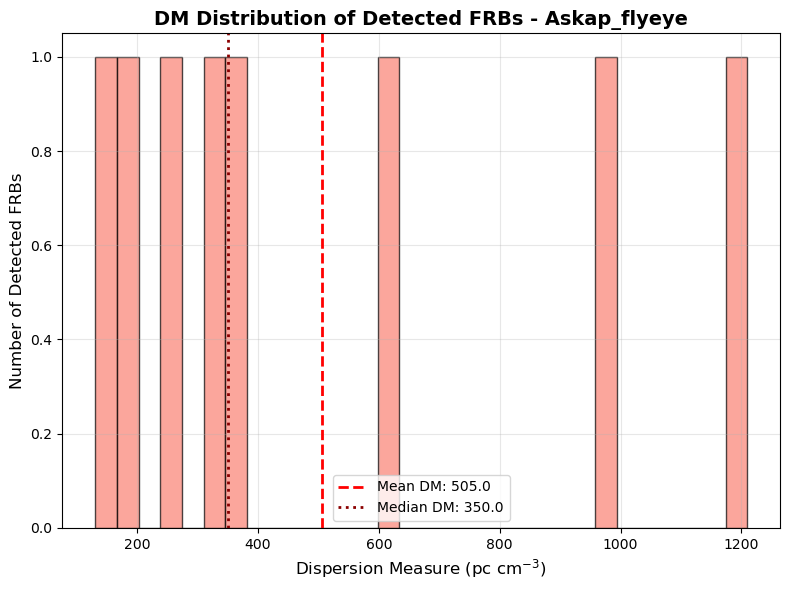

In [ ]:
from pathlib import Path
valid_mask = ~np.isnan(all_alpha_inferred)
dm_detected = all_dm[valid_mask]

plt.figure(figsize=(8, 6), dpi=100)
plt.hist(dm_detected, bins=30, color='salmon', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(dm_detected), color='red', linestyle='--', linewidth=2, 
            label=f'Mean DM: {np.mean(dm_detected):.1f}')
plt.axvline(np.median(dm_detected), color='darkred', linestyle=':', linewidth=2, 
            label=f'Median DM: {np.median(dm_detected):.1f}')

plt.xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=12)
plt.ylabel('Number of Detected FRBs', fontsize=12)
plt.title(f'DM Distribution of Detected FRBs - {TELESCOPE}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the DM array
file_name = f"dm_detected_askap_{ alpha_intrinsic}_flyeye_{z_array[0]:.2f}_{z_array[-1]:.2f}.npy"
out_path =Path("/home/thsu/FRB_population/ASKAP_flyeye_DM")/file_name
# out_path =Path("/Users/xuziying/Desktop/VScode/FRB_population/DM_distribution_stdc")/file_name

# Save
# np.save(out_path, dm_detected)
print(f"Saved {len(dm_detected)} DM values to 'dm_detected_askap_{ alpha_intrinsic}_flyeye_{z_array[0]:.2f}_{z_array[-1]:.2f}.npy'")

plt.show()